# Volume experiment — b-approximated polytope ratio

For each quantization bit-width $b$, plots:
$$\frac{\sum_{i} \text{vol}^b_i}{\sum_{i} \text{vol}^{\mathrm{correct}}_i}$$
where the sums run over all samples $i$ in the result files.
A ratio close to 1 means the quantized model preserves almost all the volume of the correct polytope.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path(os.getcwd()).parent
print("Project root:", ROOT)

Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Load results

In [2]:
RESULTS_DIR = ROOT / "results" / "volumes_smoke"  # change to "volumes" for the full run

files = sorted(RESULTS_DIR.glob("volumes_sample*.json"))
print(f"Found {len(files)} result files.")

records = []
for f in files:
    with open(f) as fh:
        records.append(json.load(fh))

# Show one record as a sanity check
records[0]

Found 1 result files.


{'sample_idx': 0,
 'model_path': 'checkpoints/fashion_mlp_best.pth',
 'data_path': 'data/fashionMNIST_correct_mlp.pt',
 'n_directions': 20,
 'n_directions_used': 20,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_correct': 39.64736960005938,
 'widths_both': {'4': 37.24465737201855,
  '6': 39.17595771152851,
  '8': 39.496459095032826,
  '10': 39.62765565079546,
  '12': 39.64126125073953,
  '16': 39.6470413186869}}

## Compute per-bits ratio

$$\text{ratio}(b) = \frac{\sum_{i} \text{vol}^b_i}{\sum_{i} \text{vol}^{\mathrm{correct}}_i}$$

In [3]:
# Collect all bit-widths from the first record (keys are strings in JSON)
bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

sum_correct = sum(r["width_correct"] for r in records)
ratios = {
    b: sum(r["widths_both"][str(b)] for r in records) / sum_correct
    for b in bits_grid
}

print(f"\nSum of correct widths over {len(records)} samples: {sum_correct:.4f}")
print("\nRatios:")
for b, ratio in ratios.items():
    print(f"  bits={b:2d}  ratio={ratio:.4f}  error={1-ratio:.4f}")

Bits grid: [4, 6, 8, 10, 12, 16]

Sum of correct widths over 1 samples: 39.6474

Ratios:
  bits= 4  ratio=0.9394  error=0.0606
  bits= 6  ratio=0.9881  error=0.0119
  bits= 8  ratio=0.9962  error=0.0038
  bits=10  ratio=0.9995  error=0.0005
  bits=12  ratio=0.9998  error=0.0002
  bits=16  ratio=1.0000  error=0.0000


## Plot

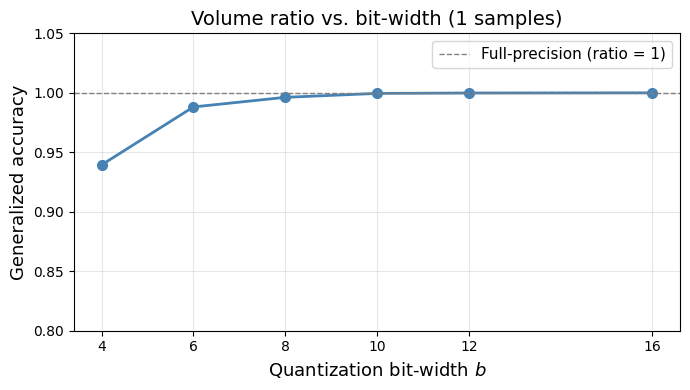

Saved to results/volumes_ratio.pdf


In [9]:
bits_arr  = np.array(bits_grid)
ratio_arr = np.array([ratios[b] for b in bits_grid])

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(bits_arr, ratio_arr, marker="o", linewidth=2, markersize=7, color="steelblue")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full-precision (ratio = 1)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel(
    "Generalized accuracy",
    fontsize=13,
)
ax.set_title(
    f"Volume ratio vs. bit-width ({len(records)} samples)",
    fontsize=14,
)
ax.set_xticks(bits_arr)
ax.set_ylim(0.8, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "volumes_ratio.pdf", bbox_inches="tight")
plt.show()
print("Saved to results/volumes_ratio.pdf")